In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

try:
    df = pd.read_csv('../data/raw/credit_risk_dataset_v1.csv')

    # Updated mapping with all 28 columns (added: age, purpose)
    df.columns = [
        'customer_id', 'age', 'banked_flag', 'job_category', 'housing_type', 'dependents',
        'employment_years', 'residence_years', 'loan_amount', 'duration_months',
        'interest_rate', 'existing_monthly_obligation', 'average_monthly_inflow',
        'average_monthly_outflow', 'emi', 'net_monthly_surplus', 'emi_coverage_ratio',
        'loan_to_income_ratio', 'existing_obligation_ratio', 'dependent_ratio',
        'employment_stability_score', 'income_variance_index', 'residence_stability_score',
        'digital_behavior_score', 'location_type', 'digital_risk_score', 'purpose', 'credit_risk'
    ]

    # 1. ENCODE CATEGORICAL DATA
    le = LabelEncoder()
    df['housing_type'] = le.fit_transform(df['housing_type'].astype(str))
    df['location_type'] = le.fit_transform(df['location_type'].astype(str))

    # 2. CLEANUP & TYPE CASTING
    df.set_index('customer_id', inplace=True)
    df = df.apply(pd.to_numeric, errors='coerce').fillna(0)

    print("✅ ALIGNMENT COMPLETE: All 28 columns mapped.")
    display(df.head())
    print(f"Dataset shape: {df.shape}")

except Exception as e:
    print(f"❌ Error: {e}")

✅ ALIGNMENT COMPLETE: All 28 columns mapped.


,age,banked_flag,job_category,housing_type,dependents,employment_years,residence_years,loan_amount,duration_months,interest_rate,...,existing_obligation_ratio,dependent_ratio,employment_stability_score,income_variance_index,residence_stability_score,digital_behavior_score,location_type,digital_risk_score,purpose,credit_risk
customer_id,,,,,,,,,,,,,,,,,,,,,
CUST0001,19,1,1,2,0,0,3,919,18,0.16,...,0.06,0.00,0.21,0.33,0.27,0.78,0,0.47,0,1
CUST0002,24,1,1,0,0,0,3,2231,12,0.14,...,0.07,0.00,0.23,0.41,0.31,0.70,0,0.38,0,1
CUST0003,18,1,1,2,1,0,3,1700,18,0.16,...,0.05,1.00,0.41,0.31,0.27,0.69,0,0.32,0,0
CUST0004,21,1,1,0,1,2,2,1166,12,0.14,...,0.06,0.25,0.41,0.32,0.39,0.76,0,0.37,0,1
CUST0005,25,1,1,2,1,0,1,631,12,0.14,...,0.07,0.12,0.37,0.52,0.26,0.75,0,0.57,0,0


Dataset shape: (1000, 27)


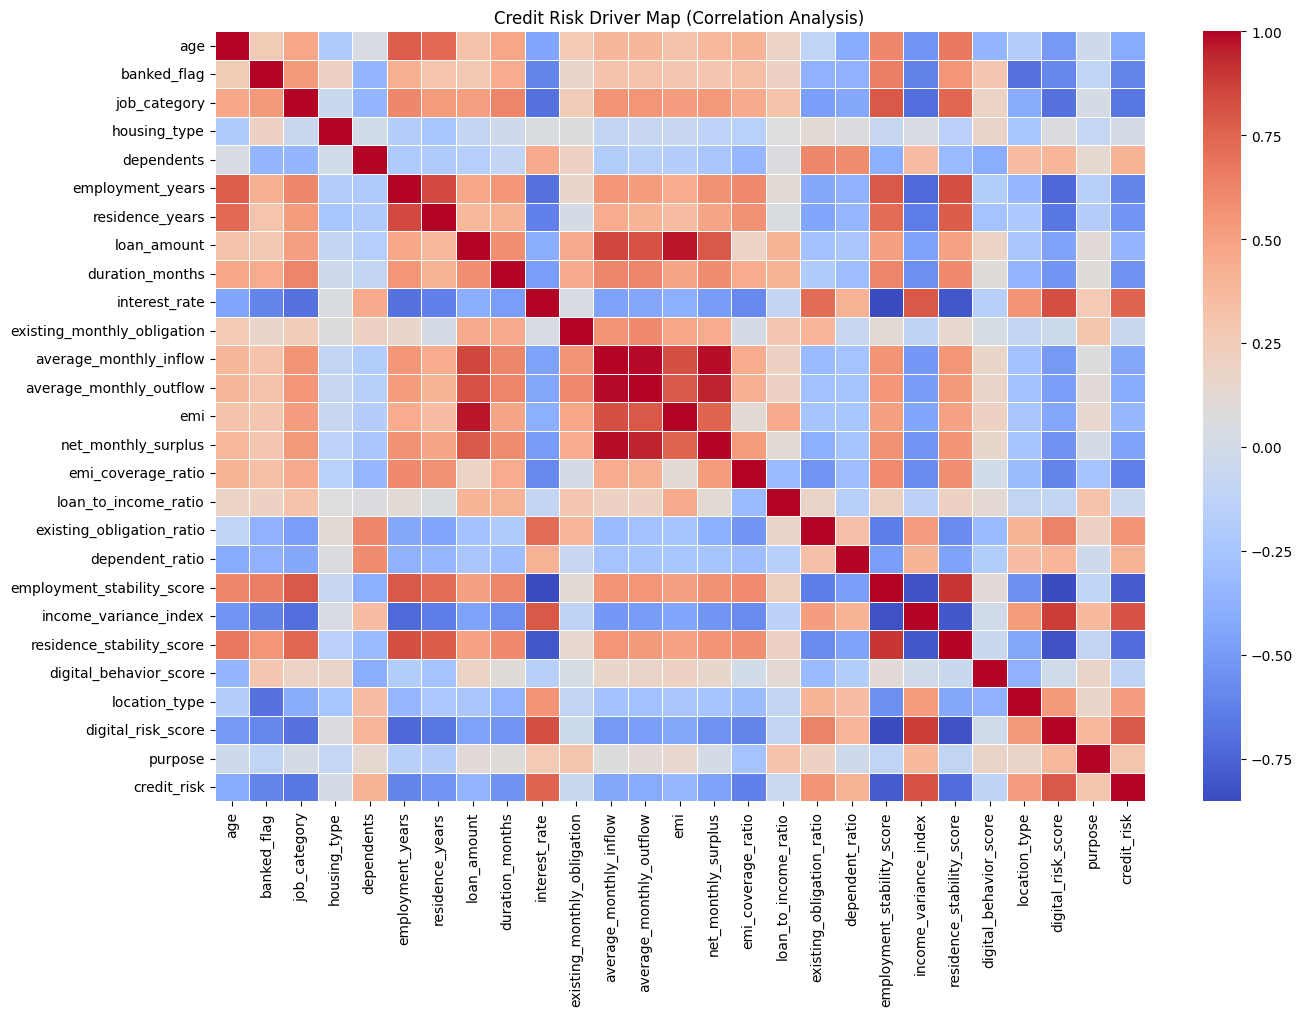

--- Top Drivers of Credit Risk ---
credit_risk                  1.000000
income_variance_index        0.812943
digital_risk_score           0.794183
interest_rate                0.749744
existing_obligation_ratio    0.563243
location_type                0.518590
Name: credit_risk, dtype: float64

--- Top Features that REDUCE Risk ---
banked_flag                  -0.608829
emi_coverage_ratio           -0.625837
job_category                 -0.668169
residence_stability_score    -0.713277
employment_stability_score   -0.785788
Name: credit_risk, dtype: float64


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate correlations
plt.figure(figsize=(15, 10))
correlation_matrix = df.corr()

# 2. Plot Heatmap
# We look for features that have high correlation (red/blue) with 'credit_risk'
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Credit Risk Driver Map (Correlation Analysis)")
plt.show()

# 3. Print the top 5 most important drivers of Risk
print("--- Top Drivers of Credit Risk ---")
risk_drivers = correlation_matrix['credit_risk'].sort_values(ascending=False)
print(risk_drivers.head(6)) # Features that increase risk
print("\n--- Top Features that REDUCE Risk ---")
print(risk_drivers.tail(5)) # Features that mean a safer customer

In [4]:
# Run this at the end of your cleaning notebook
df.to_csv('../data/processed/cleaned_credit_data.csv', index=True)
print("✅ Cleaned data saved!")

✅ Cleaned data saved!


In [3]:
# Run this once to install everything in your environment
! pip install pandas numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn shap os

ERROR: Could not find a version that satisfies the requirement os (from versions: none)
ERROR: No matching distribution found for os
